In [ ]:
!pip install -q streamlit pandas scikit-learn

In [ ]:
from io import StringIO
import pandas as pd

csv_data = r'''
course_id,course_name,category,level,skills,duration_hours,rating,instructor,platform,course_url
1,Python for Data Science and Machine Learning Bootcamp,Data Science,Beginner,python pandas numpy matplotlib data analysis machine learning,25,4.7,Jose Portilla,Udemy,https://www.udemy.com/course/python-for-data-science-and-machine-learning-bootcamp/
2,Python for Machine Learning & Data Science Masterclass,Machine Learning,Intermediate,python regression classification scikit-learn feature engineering,44,4.8,Jose Portilla,Udemy,https://www.udemy.com/course/python-for-machine-learning-data-science-masterclass/
3,TensorFlow Developer Certificate: Zero to Mastery,Artificial Intelligence,Advanced,python tensorflow neural networks deep learning computer vision,64,4.7,Daniel Bourke,Udemy,https://www.udemy.com/course/tensorflow-developer-certificate-machine-learning-zero-to-mastery/
4,SQL - MySQL for Data Analytics and Business Intelligence,Data Engineering,Beginner,sql mysql databases joins querying analytics business intelligence,25,4.7,365 Careers,Udemy,https://www.udemy.com/course/sql-mysql-for-data-analytics-and-business-intelligence/
5,Microsoft Power BI Desktop for Business Intelligence,Data Analytics,Beginner,power bi dax power query visualization dashboards business intelligence,18,4.7,Maven Analytics,Udemy,https://www.udemy.com/course/microsoft-power-bi-up-running-with-power-bi-desktop/
6,NLP - Natural Language Processing with Python,Artificial Intelligence,Advanced,python nlp nltk spacy text classification machine learning,12,4.6,Jose Portilla,Udemy,https://www.udemy.com/course/nlp-natural-language-processing-with-python/
7,The Complete Full-Stack Web Development Bootcamp,Web Development,Intermediate,html css javascript node react postgresql web development,62,4.7,Dr. Angela Yu,Udemy,https://www.udemy.com/course/the-complete-web-development-bootcamp/
8,Java Data Structures & Algorithms + LEETCODE Exercises,Software Engineering,Intermediate,java arrays linked lists trees graphs algorithms leetcode,24,4.8,Scott Barrett,Udemy,https://www.udemy.com/course/data-structures-and-algorithms-java/
9,Ultimate AWS Certified Solutions Architect Associate,Cloud Computing,Intermediate,aws cloud ec2 s3 iam lambda architecture certification,27,4.7,Stephane Maarek,Udemy,https://www.udemy.com/course/aws-certified-solutions-architect-associate-saa-c03/
10,Cybersecurity Essentials,Cybersecurity,Beginner,cybersecurity threats risk management network security cryptography,8,4.5,Udemy Instructor,Udemy,https://www.udemy.com/course/cybersecurity-essentials/
11,Python for Computer Vision with OpenCV and Deep Learning,Artificial Intelligence,Advanced,python opencv image processing computer vision deep learning yolo,14,4.6,Jose Portilla,Udemy,https://www.udemy.com/course/python-for-computer-vision-with-opencv-and-deep-learning/
12,Taming Big Data with Apache Spark and Python,Data Engineering,Advanced,python spark pyspark big data rdd dataframe machine learning,7,4.6,Sundog Education,Udemy,https://www.udemy.com/course/taming-big-data-with-apache-spark-hands-on/
13,Git Complete: The Definitive Guide to Git,Software Engineering,Beginner,git github version control branching merging collaboration,7,4.6,Jason Taylor,Udemy,https://www.udemy.com/course/git-complete/
14,The Complete Android 14 & Kotlin Development Masterclass,Mobile Development,Intermediate,kotlin android studio mobile application firebase,65,4.6,Denis Panjuta,Udemy,https://www.udemy.com/course/android-kotlin-developer/
15,Mastering Data Structures & Algorithms using C and C++,Software Engineering,Advanced,c c++ algorithms arrays linked lists trees graphs recursion,58,4.7,Abdul Bari,Udemy,https://www.udemy.com/course/datastructurescncpp/
16,Complete Generative AI Course With LangChain and Hugging Face,Artificial Intelligence,Intermediate,python generative ai llm langchain hugging face rag agents,54,4.6,Krish Naik,Udemy,https://www.udemy.com/course/complete-generative-ai-course-with-langchain-and-huggingface/
17,Statistics for Data Science and Business Analysis,Data Science,Intermediate,statistics probability hypothesis testing distributions regression,5,4.6,365 Careers,Udemy,https://www.udemy.com/course/statistics-for-data-science-and-business-analysis/
18,Docker and Kubernetes: The Complete Guide,Cloud Computing,Intermediate,docker kubernetes devops ci cd containers deployment,22,4.7,Stephen Grider,Udemy,https://www.udemy.com/course/docker-and-kubernetes-the-complete-guide/
19,User Experience Design Essentials - Adobe XD UI UX Design,Design,Beginner,ui ux adobe xd wireframes prototyping user experience design,10,4.6,Daniel Walter Scott,Udemy,https://www.udemy.com/course/ui-ux-web-design-using-adobe-xd/
20,Arduino Step by Step: Getting Started,Electronics,Beginner,arduino sensors electronics embedded systems iot prototyping,16,4.6,Tech Explorations,Udemy,https://www.udemy.com/course/arduino-sbs-17gs/
21,Ethereum and Solidity: The Complete Developer's Guide,Emerging Technology,Advanced,blockchain ethereum solidity smart contracts web3,24,4.6,Stephen Grider,Udemy,https://www.udemy.com/course/ethereum-and-solidity-the-complete-developers-guide/
22,Microsoft Excel - Excel from Beginner to Advanced,Data Analytics,Beginner,excel formulas pivot tables dashboards data cleaning analysis,22,4.7,Kyle Pew,Udemy,https://www.udemy.com/course/microsoft-excel-2013-from-beginner-to-advanced-and-beyond/
23,Recommender Systems and Deep Learning in Python,Machine Learning,Advanced,python recommender systems collaborative filtering matrix factorization deep learning,13,4.6,Lazy Programmer,Udemy,https://www.udemy.com/course/recommender-systems/
24,Python for Time Series Data Analysis,Machine Learning,Advanced,python time series forecasting arima statsmodels business analytics,12,4.6,Jose Portilla,Udemy,https://www.udemy.com/course/python-for-time-series-data-analysis/
25,FastAPI - The Complete Course,Software Engineering,Intermediate,python fastapi rest api backend authentication database,19,4.7,Eric Roby,Udemy,https://www.udemy.com/course/fastapi-the-complete-course/
26,"Machine Learning A-Z: AI, Python & R",Machine Learning,Beginner,python r machine learning regression classification clustering reinforcement learning,42,4.6,Kirill Eremenko,Udemy,https://www.udemy.com/course/machinelearning/
27,"Deep Learning A-Z: Neural Networks, AI & ChatGPT",Artificial Intelligence,Intermediate,python deep learning neural networks cnn rnn autoencoders ai,26,4.6,Kirill Eremenko,Udemy,https://www.udemy.com/course/deeplearning/
28,The Data Science Course: Complete Data Science Bootcamp,Data Science,Beginner,statistics python mathematics machine learning deep learning data science,32,4.6,365 Careers,Udemy,https://www.udemy.com/course/the-data-science-course-complete-data-science-bootcamp/
29,Complete Python Bootcamp From Zero to Hero in Python,Programming,Beginner,python programming functions object oriented programming projects,22,4.6,Jose Portilla,Udemy,https://www.udemy.com/course/complete-python-bootcamp/
30,Tableau A-Z: Hands-On Tableau Training for Data Science,Data Analytics,Beginner,tableau dashboards visualization business intelligence analytics,9,4.6,Kirill Eremenko,Udemy,https://www.udemy.com/course/tableau10/
31,The Complete JavaScript Course: From Zero to Expert,Web Development,Intermediate,javascript es6 object oriented programming web apps projects,69,4.7,Jonas Schmedtmann,Udemy,https://www.udemy.com/course/the-complete-javascript-course/
32,React - The Complete Guide,Web Development,Intermediate,react javascript redux hooks frontend web development,68,4.6,Maximilian Schwarzmüller,Udemy,https://www.udemy.com/course/react-the-complete-guide-incl-redux/
33,The Complete Node.js Developer Course,Web Development,Intermediate,nodejs express mongodb rest api backend javascript,35,4.6,Andrew Mead,Udemy,https://www.udemy.com/course/the-complete-nodejs-developer-course-2/
34,Complete Linux Training Course to Get Your Dream IT Job,Cloud Computing,Beginner,linux shell scripting system administration networking devops,44,4.6,Imran Afzal,Udemy,https://www.udemy.com/course/complete-linux-training-course-to-get-your-dream-it-job/
35,The Complete SQL Bootcamp: Go from Zero to Hero,Data Engineering,Beginner,sql postgresql joins window functions database analytics,9,4.7,Jose Portilla,Udemy,https://www.udemy.com/course/the-complete-sql-bootcamp/
'''

df = pd.read_csv(StringIO(csv_data))
df.head()

print("Shape:", df.shape)
display(df.info())
display(df["category"].value_counts())
display(df.describe())

df["combined_features"] = (
    df["course_name"] + " " +
    df["category"] + " " +
    df["level"] + " " +
    df["skills"] + " " +
    df["instructor"]
).str.lower()

df[["course_name", "combined_features"]].head()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Convert the combined text into TF-IDF vectors
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

course_matrix = vectorizer.fit_transform(
    df["combined_features"]
)

print("TF-IDF matrix shape:", course_matrix.shape)
print(
    "Sample vocabulary:",
    vectorizer.get_feature_names_out()[:20]
)
def recommend_courses(
    interests,
    preferred_level="Intermediate",
    max_duration=30,
    top_n=5
):
    """
    Recommend Udemy courses based on:
    - Student interests
    - Preferred difficulty level
    - Maximum course duration
    """

    # Combine the student's interests and preferred level
    profile_text = (
        f"{interests} {preferred_level}"
    ).lower()

    # Transform the student profile using the same TF-IDF model
    profile_vector = vectorizer.transform(
        [profile_text]
    )

    # Calculate similarity between student profile and all courses
    similarity_scores = cosine_similarity(
        profile_vector,
        course_matrix
    ).flatten()

    # Copy dataset so the original dataframe remains unchanged
    results = df.copy()

    results["match_score"] = similarity_scores

    # Filter courses according to maximum duration
    results = results[
        results["duration_hours"] <= max_duration
    ].copy()

    # Give a small bonus to courses matching the preferred level
    results["level_bonus"] = (
        results["level"]
        .eq(preferred_level)
        .astype(float)
        * 0.08
    )

    # Final ranking score
    results["final_score"] = (
        results["match_score"] +
        results["level_bonus"]
    )

    # Convert similarity score into percentage for readability
    results["match_percentage"] = (
        results["match_score"] * 100
    ).round(2)

    columns = [
        "course_name",
        "category",
        "level",
        "skills",
        "duration_hours",
        "rating",
        "instructor",
        "platform",
        "course_url",
        "match_score",
        "match_percentage"
    ]

    recommendations = (
        results
        .sort_values(
            by=[
                "final_score",
                "rating"
            ],
            ascending=[
                False,
                False
            ]
        )
        .head(top_n)[columns]
        .reset_index(drop=True)
    )

    return recommendations


Shape: (35, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   course_id       35 non-null     int64  
 1   course_name     35 non-null     object 
 2   category        35 non-null     object 
 3   level           35 non-null     object 
 4   skills          35 non-null     object 
 5   duration_hours  35 non-null     int64  
 6   rating          35 non-null     float64
 7   instructor      35 non-null     object 
 8   platform        35 non-null     object 
 9   course_url      35 non-null     object 
dtypes: float64(1), int64(2), object(7)
memory usage: 2.9+ KB


None

,count
category,
Artificial Intelligence,5
Machine Learning,4
Web Development,4
Software Engineering,4
Data Engineering,3
Data Science,3
Data Analytics,3
Cloud Computing,3
Cybersecurity,1


,course_id,duration_hours,rating
count,35.000000,35.000000,35.000000
mean,18.000000,28.942857,4.642857
std,10.246951,20.071846,0.065465
min,1.000000,5.000000,4.500000
25%,9.500000,12.500000,4.600000
50%,18.000000,24.000000,4.600000
75%,26.500000,43.000000,4.700000
max,35.000000,69.000000,4.800000


TF-IDF matrix shape: (35, 730)
Sample vocabulary: ['14' '14 kotlin' '365' '365 careers' 'abdul' 'abdul bari'
 'administration' 'administration networking' 'adobe' 'adobe xd'
 'advanced' 'advanced algorithms' 'advanced blockchain' 'advanced data'
 'advanced python' 'afzal' 'agents' 'agents krish' 'ai' 'ai chatgpt']


In [ ]:
recommendations = recommend_courses(
    interests=(
        "machine learning python statistics "
        "artificial intelligence"
    ),
    preferred_level="Intermediate",
    max_duration=30,
    top_n=5
)

recommendations

,course_name,category,level,skills,duration_hours,rating,instructor,platform,course_url,match_score,match_percentage
0,"Deep Learning A-Z: Neural Networks, AI & ChatGPT",Artificial Intelligence,Intermediate,python deep learning neural networks cnn rnn a...,26,4.6,Kirill Eremenko,Udemy,https://www.udemy.com/course/deeplearning/,0.220151,22.02
1,NLP - Natural Language Processing with Python,Artificial Intelligence,Advanced,python nlp nltk spacy text classification mach...,12,4.6,Jose Portilla,Udemy,https://www.udemy.com/course/nlp-natural-langu...,0.232495,23.25
2,Statistics for Data Science and Business Analysis,Data Science,Intermediate,statistics probability hypothesis testing dist...,5,4.6,365 Careers,Udemy,https://www.udemy.com/course/statistics-for-da...,0.147957,14.80
3,Recommender Systems and Deep Learning in Python,Machine Learning,Advanced,python recommender systems collaborative filte...,13,4.6,Lazy Programmer,Udemy,https://www.udemy.com/course/recommender-systems/,0.213297,21.33
4,Python for Data Science and Machine Learning B...,Data Science,Beginner,python pandas numpy matplotlib data analysis m...,25,4.7,Jose Portilla,Udemy,https://www.udemy.com/course/python-for-data-s...,0.203009,20.30


In [ ]:
from IPython.display import display, HTML

def display_recommendations(recommendations):
    for index, row in recommendations.iterrows():

        display(
            HTML(
                f"""
                <div style="
                    border: 1px solid #dddddd;
                    padding: 16px;
                    margin-bottom: 12px;
                    border-radius: 10px;
                ">
                    <h3>
                        {index + 1}. {row["course_name"]}
                    </h3>

                    <p>
                        <b>Instructor:</b>
                        {row["instructor"]}
                    </p>

                    <p>
                        <b>Category:</b>
                        {row["category"]}
                        |
                        <b>Level:</b>
                        {row["level"]}
                    </p>

                    <p>
                        <b>Duration:</b>
                        {row["duration_hours"]} hours
                        |
                        <b>Rating:</b>
                        {row["rating"]}/5
                    </p>

                    <p>
                        <b>Match:</b>
                        {row["match_percentage"]}%
                    </p>

                    <p>
                        <b>Skills:</b>
                        {row["skills"]}
                    </p>

                    <a
                        href="{row["course_url"]}"
                        target="_blank"
                        style="
                            display: inline-block;
                            background-color: #a435f0;
                            color: white;
                            padding: 10px 16px;
                            border-radius: 6px;
                            text-decoration: none;
                            font-weight: bold;
                        "
                    >
                        Open Udemy Course
                    </a>
                </div>
                """
            )
        )

In [ ]:
display_recommendations(recommendations)

In [ ]:
test_cases = [
    (
        "python machine learning classification",
        "Python for Machine Learning & Data Science Masterclass"
    ),
    (
        "sql database analytics",
        "SQL - MySQL for Data Analytics and Business Intelligence"
    ),
    (
        "react javascript web development",
        "React - The Complete Guide"
    ),
    (
        "aws cloud devops",
        "Ultimate AWS Certified Solutions Architect Associate"
    ),
    (
        "nlp text classification",
        "NLP - Natural Language Processing with Python"
    )
]

def hit_rate_at_k(test_cases, k=5):
    hits = 0
    details = []

    for query, expected in test_cases:

        recommendations = recommend_courses(
            query,
            preferred_level="Intermediate",
            max_duration=100,
            top_n=k
        )

        names = recommendations["course_name"].tolist()

        hit = expected in names
        hits += int(hit)

        details.append({
            "query": query,
            "expected": expected,
            "recommended_courses": names,
            "hit": hit
        })

    return hits / len(test_cases), pd.DataFrame(details)


score, evaluation_details = hit_rate_at_k(
    test_cases,
    k=5
)

print(f"Hit Rate@5: {score:.2%}")
evaluation_details

Hit Rate@5: 100.00%


,query,expected,recommended_courses,hit
0,python machine learning classification,Python for Machine Learning & Data Science Mas...,"[Machine Learning A-Z: AI, Python & R, Python ...",True
1,sql database analytics,SQL - MySQL for Data Analytics and Business In...,[The Complete SQL Bootcamp: Go from Zero to He...,True
2,react javascript web development,React - The Complete Guide,"[React - The Complete Guide, The Complete Full...",True
3,aws cloud devops,Ultimate AWS Certified Solutions Architect Ass...,[Ultimate AWS Certified Solutions Architect As...,True
4,nlp text classification,NLP - Natural Language Processing with Python,[NLP - Natural Language Processing with Python...,True


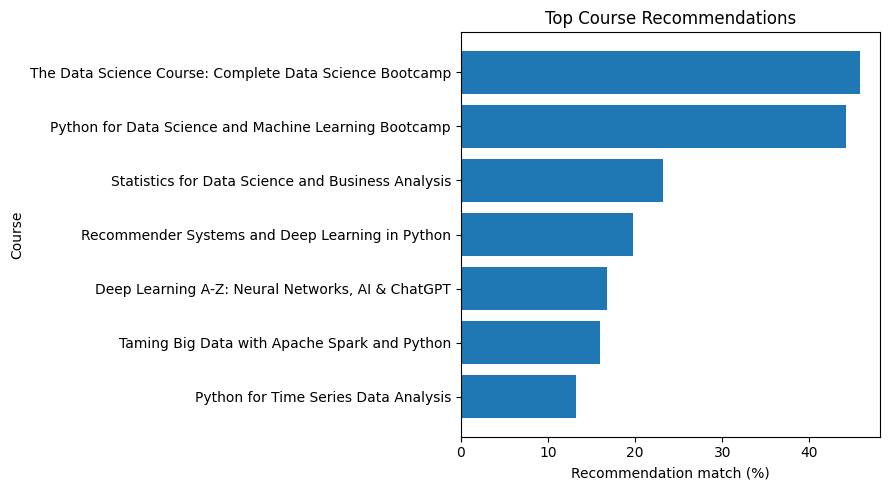

In [ ]:
import matplotlib.pyplot as plt

sample = recommend_courses(
    interests="data science python machine learning AI",
    preferred_level="Intermediate",
    max_duration=40,
    top_n=7
).sort_values("match_percentage")

plt.figure(figsize=(9, 5))

plt.barh(
    sample["course_name"],
    sample["match_percentage"]
)

plt.xlabel("Recommendation match (%)")
plt.ylabel("Course")
plt.title("Top Course Recommendations")
plt.tight_layout()
plt.show()

In [ ]:
with open("courses.csv", "w") as f:
    f.write('''course_id,course_name,category,level,skills,duration_hours,rating,instructor,platform,course_url
1,Python for Data Science and Machine Learning Bootcamp,Data Science,Beginner,"python pandas numpy matplotlib data analysis machine learning",25,4.7,Jose Portilla,Udemy,https://www.udemy.com/course/python-for-data-science-and-machine-learning-bootcamp/
2,Python for Machine Learning & Data Science Masterclass,Machine Learning,Intermediate,"python regression classification scikit-learn feature engineering",44,4.8,Jose Portilla,Udemy,https://www.udemy.com/course/python-for-machine-learning-data-science-masterclass/
3,TensorFlow Developer Certificate: Zero to Mastery,Artificial Intelligence,Advanced,"python tensorflow neural networks deep learning computer vision",64,4.7,Daniel Bourke,Udemy,https://www.udemy.com/course/tensorflow-developer-certificate-machine-learning-zero-to-mastery/
4,SQL - MySQL for Data Analytics and Business Intelligence,Data Engineering,Beginner,"sql mysql databases joins querying analytics business intelligence",25,4.7,365 Careers,Udemy,https://www.udemy.com/course/sql-mysql-for-data-analytics-and-business-intelligence/
5,Microsoft Power BI Desktop for Business Intelligence,Data Analytics,Beginner,"power bi dax power query visualization dashboards business intelligence",18,4.7,Maven Analytics,Udemy,https://www.udemy.com/course/microsoft-power-bi-up-running-with-power-bi-desktop/
6,NLP - Natural Language Processing with Python,Artificial Intelligence,Advanced,"python nlp nltk spacy text classification machine learning",12,4.6,Jose Portilla,Udemy,https://www.udemy.com/course/nlp-natural-language-processing-with-python/
7,The Complete Full-Stack Web Development Bootcamp,Web Development,Intermediate,"html css javascript node react postgresql web development",62,4.7,Dr. Angela Yu,Udemy,https://www.udemy.com/course/the-complete-web-development-bootcamp/
8,Java Data Structures & Algorithms + LEETCODE Exercises,Software Engineering,Intermediate,"java arrays linked lists trees graphs algorithms leetcode",24,4.8,Scott Barrett,Udemy,https://www.udemy.com/course/data-structures-and-algorithms-java/
9,Ultimate AWS Certified Solutions Architect Associate,Cloud Computing,Intermediate,"aws cloud ec2 s3 iam lambda architecture certification",27,4.7,Stephane Maarek,Udemy,https://www.udemy.com/course/aws-certified-solutions-architect-associate-saa-c03/
10,Cybersecurity Essentials,Cybersecurity,Beginner,"cybersecurity threats risk management network security cryptography",8,4.5,Udemy Instructor,Udemy,https://www.udemy.com/course/cybersecurity-essentials/
11,Python for Computer Vision with OpenCV and Deep Learning,Artificial Intelligence,Advanced,"python opencv image processing computer vision deep learning yolo",14,4.6,Jose Portilla,Udemy,https://www.udemy.com/course/python-for-computer-vision-with-opencv-and-deep-learning/
12,Taming Big Data with Apache Spark and Python,Data Engineering,Advanced,"python spark pyspark big data rdd dataframe machine learning",7,4.6,Sundog Education,Udemy,https://www.udemy.com/course/taming-big-data-with-apache-spark-hands-on/
13,Git Complete: The Definitive Guide to Git,Software Engineering,Beginner,"git github version control branching merging collaboration",7,4.6,Jason Taylor,Udemy,https://www.udemy.com/course/git-complete/
14,The Complete Android 14 & Kotlin Development Masterclass,Mobile Development,Intermediate,"kotlin android studio mobile application firebase",65,4.6,Denis Panjuta,Udemy,https://www.udemy.com/course/android-kotlin-developer/
15,Mastering Data Structures & Algorithms using C and C++,Software Engineering,Advanced,"c c++ algorithms arrays linked lists trees graphs recursion",58,4.7,Abdul Bari,Udemy,https://www.udemy.com/course/datastructurescncpp/
16,Complete Generative AI Course With LangChain and Hugging Face,Artificial Intelligence,Intermediate,"python generative ai llm langchain hugging face rag agents",54,4.6,Krish Naik,Udemy,https://www.udemy.com/course/complete-generative-ai-course-with-langchain-and-huggingface/
17,Statistics for Data Science and Business Analysis,Data Science,Intermediate,"statistics probability hypothesis testing distributions regression",5,4.6,365 Careers,Udemy,https://www.udemy.com/course/statistics-for-data-science-and-business-analysis/
18,Docker and Kubernetes: The Complete Guide,Cloud Computing,Intermediate,"docker kubernetes devops ci cd containers deployment",22,4.7,Stephen Grider,Udemy,https://www.udemy.com/course/docker-and-kubernetes-the-complete-guide/
19,User Experience Design Essentials - Adobe XD UI UX Design,Design,Beginner,"ui ux adobe xd wireframes prototyping user experience design",10,4.6,Daniel Walter Scott,Udemy,https://www.udemy.com/course/ui-ux-web-design-using-adobe-xd/
20,Arduino Step by Step: Getting Started,Electronics,Beginner,"arduino sensors electronics embedded systems iot prototyping",16,4.6,Tech Explorations,Udemy,https://www.udemy.com/course/arduino-sbs-17gs/
21,Ethereum and Solidity: The Complete Developer's Guide,Emerging Technology,Advanced,"blockchain ethereum solidity smart contracts web3",24,4.6,Stephen Grider,Udemy,https://www.udemy.com/course/ethereum-and-solidity-the-complete-developers-guide/
22,Microsoft Excel - Excel from Beginner to Advanced,Data Analytics,Beginner,"excel formulas pivot tables dashboards data cleaning analysis",22,4.7,Kyle Pew,Udemy,https://www.udemy.com/course/microsoft-excel-2013-from-beginner-to-advanced-and-beyond/
23,Recommender Systems and Deep Learning in Python,Machine Learning,Advanced,"python recommender systems collaborative filtering matrix factorization deep learning",13,4.6,Lazy Programmer,Udemy,https://www.udemy.com/course/recommender-systems/
24,Python for Time Series Data Analysis,Machine Learning,Advanced,"python time series forecasting arima statsmodels business analytics",12,4.6,Jose Portilla,Udemy,https://www.udemy.com/course/python-for-time-series-data-analysis/
25,FastAPI - The Complete Course,Software Engineering,Intermediate,"python fastapi rest api backend authentication database",19,4.7,Eric Roby,Udemy,https://www.udemy.com/course/fastapi-the-complete-course/
26,Machine Learning A-Z: AI Python & R,Machine Learning,Beginner,"python r machine learning regression classification clustering reinforcement learning",42,4.6,Kirill Eremenko,Udemy,https://www.udemy.com/course/machinelearning/
27,Deep Learning A-Z: Neural Networks AI & ChatGPT,Artificial Intelligence,Intermediate,"python deep learning neural networks cnn rnn autoencoders ai",26,4.6,Kirill Eremenko,Udemy,https://www.udemy.com/course/deeplearning/
28,The Data Science Course: Complete Data Science Bootcamp,Data Science,Beginner,"statistics python mathematics machine learning deep learning data science",32,4.6,365 Careers,Udemy,https://www.udemy.com/course/the-data-science-course-complete-data-science-bootcamp/
29,Complete Python Bootcamp From Zero to Hero in Python,Programming,Beginner,"python programming functions object oriented programming projects",22,4.6,Jose Portilla,Udemy,https://www.udemy.com/course/complete-python-bootcamp/
30,Tableau A-Z: Hands-On Tableau Training for Data Science,Data Analytics,Beginner,"tableau dashboards visualization business intelligence analytics",9,4.6,Kirill Eremenko,Udemy,https://www.udemy.com/course/tableau10/
31,The Complete JavaScript Course: From Zero to Expert,Web Development,Intermediate,"javascript es6 object oriented programming web apps projects",69,4.7,Jonas Schmedtmann,Udemy,https://www.udemy.com/course/the-complete-javascript-course/
32,React - The Complete Guide,Web Development,Intermediate,"react javascript redux hooks frontend web development",68,4.6,Maximilian Schwarzmüller,Udemy,https://www.udemy.com/course/react-the-complete-guide-incl-redux/
33,The Complete Node.js Developer Course,Web Development,Intermediate,"nodejs express mongodb rest api backend javascript",35,4.6,Andrew Mead,Udemy,https://www.udemy.com/course/the-complete-nodejs-developer-course-2/
34,Complete Linux Training Course to Get Your Dream IT Job,Cloud Computing,Beginner,"linux shell scripting system administration networking devops",44,4.6,Imran Afzal,Udemy,https://www.udemy.com/course/complete-linux-training-course-to-get-your-dream-it-job/
35,The Complete SQL Bootcamp: Go from Zero to Hero,Data Engineering,Beginner,"sql postgresql joins window functions database analytics",9,4.7,Jose Portilla,Udemy,https://www.udemy.com/course/the-complete-sql-bootcamp/
''')


app_code = r'''
import pandas as pd
import streamlit as st

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


st.set_page_config(
    page_title="Udemy Course Recommender",
    page_icon="🎓",
    layout="wide"
)


@st.cache_data
def load_data():
    df = pd.read_csv("courses.csv")

    text_columns = [
        "course_name",
        "category",
        "level",
        "skills",
        "instructor"
    ]

    for column in text_columns:
        df[column] = df[column].fillna("")

    return df


@st.cache_resource
def build_model(df):
    model_df = df.copy()

    model_df["combined_features"] = (
        model_df["course_name"] + " " +
        model_df["category"] + " " +
        model_df["level"] + " " +
        model_df["skills"] + " " +
        model_df["instructor"]
    ).str.lower()

    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2)
    )

    course_matrix = vectorizer.fit_transform(
        model_df["combined_features"]
    )

    return model_df, vectorizer, course_matrix


def recommend_courses(
    query,
    preferred_level,
    max_duration,
    df,
    vectorizer,
    course_matrix,
    top_n=5
):
    profile_text = f"{query} {preferred_level}".lower()

    profile_vector = vectorizer.transform(
        [profile_text]
    )

    similarity_scores = cosine_similarity(
        profile_vector,
        course_matrix
    ).flatten()

    results = df.copy()

    results["match_score"] = similarity_scores

    results = results[
        results["duration_hours"] <= max_duration
    ].copy()

    results["level_bonus"] = (
        results["level"]
        .eq(preferred_level)
        .astype(float)
        * 0.08
    )

    results["rating_bonus"] = (
        results["rating"] / 5
    ) * 0.02

    results["final_score"] = (
        results["match_score"] +
        results["level_bonus"] +
        results["rating_bonus"]
    )

    results["match_percentage"] = (
        results["match_score"] * 100
    ).round(1)

    return (
        results
        .sort_values(
            ["final_score", "rating"],
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


df = load_data()
df, vectorizer, course_matrix = build_model(df)


st.title("🎓 Engineering Course Recommendation System")

st.write(
    """
    Discover relevant Udemy courses based on your career goal,
    technical interests, preferred difficulty and available learning time.
    """
)


with st.sidebar:
    st.header("Student Profile")

    interests = st.text_area(
        "Skills, interests or career goal",
        (
            "I want to become a machine learning engineer "
            "and learn Python, statistics and artificial intelligence."
        ),
        height=130
    )

    preferred_level = st.selectbox(
        "Preferred course level",
        ["Beginner", "Intermediate", "Advanced"]
    )

    max_duration = st.slider(
        "Maximum course duration",
        min_value=5,
        max_value=80,
        value=40,
        step=1
    )

    top_n = st.slider(
        "Number of recommendations",
        min_value=3,
        max_value=10,
        value=5
    )

    recommend_button = st.button(
        "Recommend Courses",
        type="primary",
        use_container_width=True
    )


if recommend_button:

    if not interests.strip():
        st.warning(
            "Please enter at least one skill, interest or career goal."
        )

    else:
        recommendations = recommend_courses(
            query=interests,
            preferred_level=preferred_level,
            max_duration=max_duration,
            df=df,
            vectorizer=vectorizer,
            course_matrix=course_matrix,
            top_n=top_n
        )

        st.subheader("Recommended Udemy Courses")

        if recommendations.empty:
            st.info(
                "No courses match the selected duration. "
                "Increase the maximum duration."
            )

        else:
            for rank, (_, row) in enumerate(
                recommendations.iterrows(),
                start=1
            ):
                with st.container(border=True):

                    content_column, metric_column = st.columns(
                        [4, 1]
                    )

                    with content_column:
                        st.markdown(
                            f"### {rank}. {row['course_name']}"
                        )

                        st.write(
                            f"**Instructor:** {row['instructor']}"
                        )

                        st.write(
                            f"**Category:** {row['category']}  |  "
                            f"**Level:** {row['level']}  |  "
                            f"**Duration:** {row['duration_hours']} hours"
                        )

                        st.write(
                            f"**Skills covered:** {row['skills']}"
                        )

                        st.link_button(
                            "Open Udemy Course ↗",
                            row["course_url"],
                            use_container_width=False
                        )

                    with metric_column:
                        st.metric(
                            "Match",
                            f"{row['match_percentage']:.1f}%"
                        )

                        st.metric(
                            "Rating",
                            f"{row['rating']}/5"
                        )

                        st.caption(
                            f"Platform: {row['platform']}"
                        )

            st.subheader("Recommendation Scores")

            chart_data = (
                recommendations[
                    ["course_name", "match_percentage"]
                ]
                .set_index("course_name")
                .sort_values("match_percentage")
            )

            st.bar_chart(
                chart_data,
                horizontal=True,
                x_label="Match percentage",
                y_label="Course"
            )


with st.expander("How does the recommendation algorithm work?"):
    st.markdown(
        """
        1. Course name, category, level, skills and instructor are combined.
        2. TF-IDF converts the course descriptions into numerical vectors.
        3. The student's interests are converted using the same vectorizer.
        4. Cosine similarity measures the similarity between the student
           profile and every course.
        5. Courses exceeding the selected duration are removed.
        6. A small bonus is added when the course level matches the
           student's preferred level.
        7. Courses are ranked using relevance and rating.
        """
    )


with st.expander("Machine-learning concepts used"):
    st.markdown(
        """
        - Content-based recommendation
        - Natural-language processing
        - Feature engineering
        - TF-IDF vectorization
        - Unigrams and bigrams
        - Cosine similarity
        - Filtering and ranking
        - Recommendation score
        """
    )


st.caption(
    "Portfolio project: Python • Pandas • Scikit-learn • "
    "TF-IDF • Cosine Similarity • Streamlit"
)
'''


with open("app.py", "w") as f:
    f.write(app_code)


print("Created updated app.py and courses.csv")
print("Number of courses: 35")

Created updated app.py and courses.csv
Number of courses: 35


In [ ]:
!streamlit run app.py --server.port 8501 --server.headless true > streamlit.log 2>&1 &
!curl -s ipv4.icanhazip.com
!npx localtunnel --port 8501

34.145.252.203
⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://true-tools-like.loca.lt
^C
